In [58]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [4]:
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame

In [6]:
X = df.drop(columns=["SalePrice"])
y=df["SalePrice"]
X.shape, y.shape

((1460, 80), (1460,))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1168, 80), (292, 80), (1168,), (292,))

In [10]:
numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns
len(numeric_features), len(categorical_features)

(37, 43)

In [14]:
numeric_features[:10]

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'],
      dtype='str')

In [12]:
categorical_features[:10]

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'],
      dtype='str')

In [23]:
numeric_imputer = SimpleImputer(strategy="median")
numeric_transformer = Pipeline(steps=[("imputer", numeric_imputer)])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [28]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)
predictions = model.predict(X_test)


In [29]:
predictions[:5]

array([156955.53655958, 348999.84653118,  93718.72750001, 181000.91916811,
       341433.78391291])

In [30]:
y_test.head()

892     154500
1105    325000
413     115000
522     159000
1036    315500
Name: SalePrice, dtype: int64

In [32]:
mae = mean_absolute_error(y_test, predictions)
mae

20548.772512977437

In [35]:
rmse = root_mean_squared_error(y_test, predictions)
rmse

31269.655901767783

In [37]:
r2 = r2_score(y_test, predictions)
r2

0.8725228427314126

In [38]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 20548.772512977437
RMSE: 31269.655901767783
R²  : 0.8725228427314126


In [40]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [41]:
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [42]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = root_mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²  :", rf_r2)

Random Forest MAE : 17487.10123287671
Random Forest RMSE: 28348.43898881241
Random Forest R²  : 0.8952281856866255


In [43]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,20548.772513,31269.655902,0.872523
1,Random Forest,17487.101233,28348.438989,0.895228


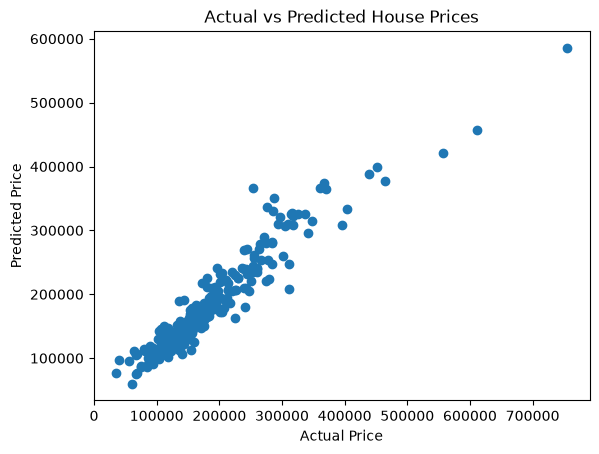

In [47]:
plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [48]:
residuals = y_test - rf_predictions

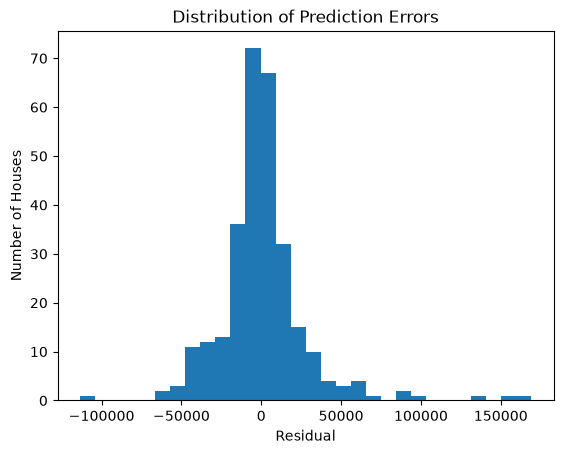

In [49]:
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Number of Houses")
plt.title("Distribution of Prediction Errors")
plt.show()

In [50]:
error_analysis = pd.DataFrame({
    "ActualPrice": y_test,
    "PredictedPrice": rf_predictions,
    "Residual": residuals
})
error_analysis["AbsoluteError"] = abs(error_analysis["Residual"])
error_analysis.sort_values(
    "AbsoluteError",
    ascending=False
).head(10)

,ActualPrice,PredictedPrice,Residual,AbsoluteError
691,755000,586042.080,168957.920,168957.920
898,611657,457523.275,154133.725,154133.725
1046,556581,421836.905,134744.095,134744.095
581,253293,366689.595,-113396.595,113396.595
218,311500,208655.705,102844.295,102844.295
1243,465000,376785.505,88214.495,88214.495
774,395000,308168.550,86831.450,86831.450
231,403000,333127.730,69872.270,69872.270
196,311872,247493.295,64378.705,64378.705
1024,287000,351011.130,-64011.130,64011.130


In [54]:
fitted_preprocessor = rf_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
rf_regressor = rf_model.named_steps["regressor"]
importances = rf_regressor.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)
feature_importance.head(15)

,Feature,Importance
4,num__OverallQual,0.554349
16,num__GrLivArea,0.122021
12,num__TotalBsmtSF,0.033696
14,num__2ndFlrSF,0.031462
13,num__1stFlrSF,0.026852
9,num__BsmtFinSF1,0.026658
3,num__LotArea,0.017572
27,num__GarageArea,0.015324
26,num__GarageCars,0.013804
6,num__YearBuilt,0.012078


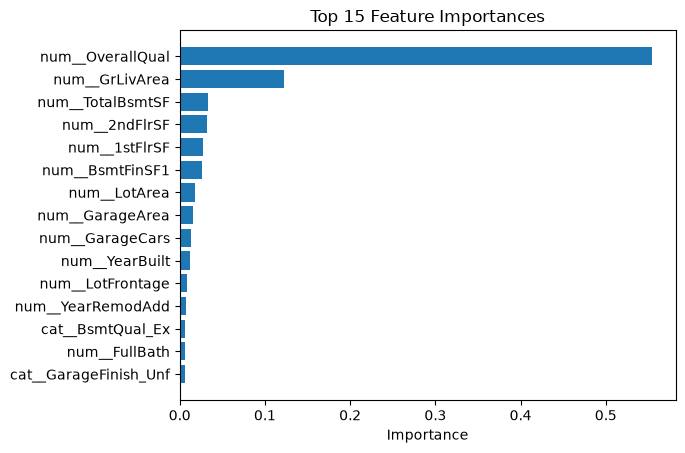

In [55]:
top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.show()

In [57]:
new_house = X_test.iloc[[0]]
predicted_price = rf_model.predict(new_house)
predicted_price
actual_price = y_test.iloc[0]
print("Predicted price:", predicted_price[0])
print("Actual price:", actual_price)
rf_model.predict(new_house)

Predicted price: 140651.0
Actual price: 154500


array([140651.])

In [59]:
joblib.dump(
    rf_model,
    "../models/house_price_model.pkl"
)

['../models/house_price_model.pkl']